# Day 02 프로젝트 실습
## 수집된 데이터 품질 및 분석

> 이 노트북은 **[데이터 품질과 전처리 이해](../데이터%20품질과%20전처리%20이해.md)** 에서 배운 이론(결측치·이상치·표현 불일치·데이터 신뢰도)을,
> **[Day 01 프로젝트에서 수집한 실데이터](../../day01_1일차/프로젝트/프로젝트_수집된%20데이터%20설명.md)** 에 직접 적용해 보는 실습입니다.

### 사용하는 데이터 (`data/` 폴더)
| 파일 | 요구사항정의서 연결 | 출처 |
| --- | --- | --- |
| `상품마스터.csv` | RF-1(맞춤 추천), RF-4(복용 정보) | 식품안전나라 건강기능식품 검색(실제 신고 데이터) |
| `영양소_기능성_추천DB_확장판.csv` | RF-2(성분 설명), RF-1(추천 매칭 기준) | MFDS 고시 「건강기능식품의 기준 및 규격」 등 |
| `영양소별_권장섭취량_확장판_한글.csv` | RF-4(권장·상한 섭취량, 과다섭취 경고) | 한국인 영양소 섭취기준(KDRIs) |

### 학습 목표
- 실제 수집한 데이터에서 결측치와 이상치를 직접 찾아본다.
- "값이 비어 있다 = 문제다"가 아니라, **왜 비어 있는지** 먼저 판단하는 연습을 한다.
- 서로 다른 파일의 표현(영양소명 등)이 일치하는지 확인해, 조인(JOIN)이 가능한 상태인지 점검한다.
- 데이터 출처·근거 수준을 확인해, RAG 챗봇(RF-3)이 인용할 수 있는 데이터인지 판단한다.
- 이 데이터로 RF-1~4 기능을 만들기에 충분한지, 부족한 부분은 무엇인지 정리한다.

---
## 0. 준비 : 라이브러리와 데이터 불러오기

`requirements.txt`에 정의된 라이브러리만 사용합니다.

```
jupyter
pandas
seaborn
koreanize-matplotlib
```

- `pandas` : 표 형태 데이터(CSV)를 다루는 라이브러리
- `seaborn` : 데이터 분포를 그래프로 확인하는 라이브러리 (결측치·이상치를 눈으로 보기 위함)
- `koreanize-matplotlib` : 그래프에 한글이 깨지지 않고 나오게 해주는 라이브러리

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import koreanize_matplotlib  # 한글 폰트 깨짐 방지

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_style("whitegrid")
koreanize_matplotlib.koreanize()  # sns.set_style이 font.family를 초기화하므로 다시 적용


In [2]:
product = pd.read_csv("data/상품마스터.csv")
func_db = pd.read_csv("data/영양소_기능성_추천DB_확장판.csv")
rda_db = pd.read_csv("data/영양소별_권장섭취량_확장판_한글.csv")

print("상품마스터:", product.shape)
print("영양소_기능성_추천DB:", func_db.shape)
print("영양소별_권장섭취량:", rda_db.shape)


상품마스터: (44, 15)
영양소_기능성_추천DB: (54, 10)
영양소별_권장섭취량: (228, 13)


In [3]:
product.head(3)

,상품ID,상품명,업소명,카테고리,검색키워드(주요원료),관련_증상,신고번호,등록일자,소비기한,성상,섭취량_섭취방법,섭취시주의사항,기능성_내용,신고번호_상세조회URL,데이터출처
0,P001,뉴메릿 비타민C&D 메가,(주)푸드어셈블,비타민,비타민 C,피로,2025001237116,2026-07-08,제조일로부터 24개월,"고유의 향미가 있고 이미, 이취가 없는 하양색의 입자성이 없는 분말","1일1회 , 1회 1포(2.1g)를 물과 함께 섭취하십시오",1. 고칼슘혈증이 있거나 의약품 복용 시 전문가와 상담할 것 / 2. 이상사례 발생...,[비타민C] / (1) 결합조직 형성과 기능유지에 필요 / (2) 철의 흡수에 필요...,https://www.foodsafetykorea.go.kr/portal/healt...,식품안전나라(foodsafetykorea.go.kr) 건강기능식품 검색
1,P002,뉴메릿 비타민C&D 듀얼 메가,(주)푸드어셈블,비타민,비타민 C,피로,2025001237117,2026-07-08,제조일로부터 24개월,"고유의 향미가 있고 이미, 이취가 없는 하양색 분말","1일 1회 , 1회 1포(3.2g)를 물과 함께 섭취하십시오.",➀ 고칼슘혈증이 있거나 의약품 복용 시 전문가와 상담할 것 / ➁ 이상사례 발생 시...,[비타민C] / (1) 결합조직 형성과 기능유지에 필요 / (2) 철의 흡수에 필요...,https://www.foodsafetykorea.go.kr/portal/healt...,식품안전나라(foodsafetykorea.go.kr) 건강기능식품 검색
2,P003,마이니 뼈건강 칼슘 마그네슘 비타민D,주식회사 노바렉스,비타민,비타민 D,골 건강,200400200083446,2026-07-09,제조일로부터 24개월,고유의 향미가 있고 이미·이취가 없는 점박이를 포함한 흰색의 흰색 장방형 제피 정제,"1일 1회, 1회 1정을 물과 함께 섭취하십시오.","특정질환, 특이체질, 알레르기체질, 임산부의 경우에는 간혹 개인에 따라 과민반응이 ...","[칼슘] 뼈와 치아 형성에 필요, 신경과 근육 기능 유지에 필요, 정상적인 혈액응고...",https://www.foodsafetykorea.go.kr/portal/healt...,식품안전나라(foodsafetykorea.go.kr) 건강기능식품 검색


In [4]:
func_db.head(3)

,영양소,분류,기능성,관련_증상,키워드,근거_수준,근거_설명,신뢰도,출처,출처_URL
0,비타민 C,비타민,항산화,피로,항산화,MFDS,식품의약품안전처에서 인정한 건강기능식품 기능성 근거,매우 높음,식품의약품안전처 고시 「건강기능식품의 기준 및 규격」,https://www.law.go.kr/admRulLsInfoP.do?admRulS...
1,비타민 C,비타민,철 흡수,빈혈,철분,MFDS,식품의약품안전처에서 인정한 건강기능식품 기능성 근거,매우 높음,식품의약품안전처 고시 「건강기능식품의 기준 및 규격」,https://www.law.go.kr/admRulLsInfoP.do?admRulS...
2,비타민 C,비타민,결합조직 형성,피부,콜라겐,MFDS,식품의약품안전처에서 인정한 건강기능식품 기능성 근거,매우 높음,식품의약품안전처 고시 「건강기능식품의 기준 및 규격」,https://www.law.go.kr/admRulLsInfoP.do?admRulS...


In [5]:
rda_db.head(3)

,영양소,연령대,성별,임신여부,수유여부,권장섭취량,충분섭취량,상한섭취량,단위,출처,기관,비고,출처_URL
0,비타민 A,19~29세,남성,해당없음,해당없음,900.0,NaN,3000,μg RAE,2025 한국인 영양소 섭취기준(KDRIs),보건복지부·한국영양학회,성인 기준 예시,https://www.mohw.go.kr/board.es?mid=a104110101...
1,비타민 A,19~29세,여성,해당없음,해당없음,700.0,NaN,3000,μg RAE,2025 한국인 영양소 섭취기준(KDRIs),보건복지부·한국영양학회,성인 기준 예시,https://www.mohw.go.kr/board.es?mid=a104110101...
2,비타민 A,30~49세,남성,해당없음,해당없음,900.0,NaN,3000,μg RAE,2025 한국인 영양소 섭취기준(KDRIs),보건복지부·한국영양학회,성인 기준 예시,https://www.mohw.go.kr/board.es?mid=a104110101...


---
## 1. 결측치(Missing Value) 확인

> **이론 복습** : 결측치는 값이 비어 있는 상태입니다. 비어 있다고 모두 같은 의미는 아니며,
> "왜 비어 있는가?", "꼭 필요한 값인가?"를 먼저 물어야 합니다. (데이터 품질과 전처리 이해.md)

세 개 파일 각각에서 컬럼별 결측치 개수와 비율을 확인합니다.

In [6]:
def missing_report(df, name):
    report = pd.DataFrame({
        "결측_개수": df.isna().sum(),
        "결측_비율(%)": (df.isna().mean() * 100).round(1),
    })
    report = report[report["결측_개수"] > 0].sort_values("결측_개수", ascending=False)
    print(f"[{name}] 결측치가 있는 컬럼")
    return report

missing_report(product, "상품마스터")


[상품마스터] 결측치가 있는 컬럼


,결측_개수,결측_비율(%)
섭취시주의사항,1,2.3


In [7]:
missing_report(func_db, "영양소_기능성_추천DB")

[영양소_기능성_추천DB] 결측치가 있는 컬럼


,결측_개수,결측_비율(%)
출처_URL,2,3.7


In [8]:
missing_report(rda_db, "영양소별_권장섭취량")

[영양소별_권장섭취량] 결측치가 있는 컬럼


,결측_개수,결측_비율(%)
충분섭취량,148,64.9
권장섭취량,82,36.0
상한섭취량,72,31.6


### 해석해보기

- `영양소별_권장섭취량`의 `충분섭취량`은 대부분 비어 있습니다. 이는 입력 실수가 아니라,
  **권장섭취량이 정해진 영양소는 충분섭취량이 없고, 반대의 경우도 있기 때문**입니다.
  (KDRIs 제도상 하나의 영양소는 권장섭취량 또는 충분섭취량 중 하나만 제시됩니다.)
- `영양소_기능성_추천DB`의 `출처_URL`이 비어 있는 2건은 Meta-analysis/Clinical Study 근거로,
  **특정 논문을 확인할 수 없어 의도적으로 비워 둔 값**입니다.

> 즉, 이 두 결측치는 "삭제하거나 채워야 할 오류"가 아니라 **정상적으로 비어 있는 값**입니다.
> 아래 실습에서 직접 확인해 봅니다.

In [9]:
# 실습 1: 권장섭취량과 충분섭취량이 "동시에" 비어 있는 행이 있는지 확인해봅시다.
# 만약 있다면 그 행은 진짜 결측치(입력 누락)일 가능성이 높습니다.
both_missing = rda_db[rda_db["권장섭취량"].isna() & rda_db["충분섭취량"].isna()]
print("권장섭취량·충분섭취량이 모두 비어 있는 행 수:", len(both_missing))
both_missing.head()


권장섭취량·충분섭취량이 모두 비어 있는 행 수: 2


,영양소,연령대,성별,임신여부,수유여부,권장섭취량,충분섭취량,상한섭취량,단위,출처,기관,비고,출처_URL
224,비타민 D,임산부,여성,예,아니오,NaN,NaN,100,μg,2025 한국인 영양소 섭취기준(KDRIs),보건복지부·한국영양학회,임신·수유부 기준 예시,https://www.mohw.go.kr/board.es?mid=a104110101...
225,비타민 D,수유부,여성,아니오,예,NaN,NaN,100,μg,2025 한국인 영양소 섭취기준(KDRIs),보건복지부·한국영양학회,임신·수유부 기준 예시,https://www.mohw.go.kr/board.es?mid=a104110101...


In [10]:
# 위 2건이 정말 "정상적인 결측"인지, 같은 영양소의 다른 행과 비교해서 검증해봅시다.
rda_db[rda_db["영양소"] == "비타민 D"][["연령대", "성별", "임신여부", "수유여부", "권장섭취량", "충분섭취량", "상한섭취량"]]


,연령대,성별,임신여부,수유여부,권장섭취량,충분섭취량,상한섭취량
16,19~29세,남성,해당없음,해당없음,NaN,10.0,100
17,19~29세,여성,해당없음,해당없음,NaN,10.0,100
18,30~49세,남성,해당없음,해당없음,NaN,10.0,100
19,30~49세,여성,해당없음,해당없음,NaN,10.0,100
20,50~64세,남성,해당없음,해당없음,NaN,10.0,100
21,50~64세,여성,해당없음,해당없음,NaN,10.0,100
22,65세 이상,남성,해당없음,해당없음,NaN,10.0,100
23,65세 이상,여성,해당없음,해당없음,NaN,10.0,100
224,임산부,여성,예,아니오,NaN,NaN,100
225,수유부,여성,아니오,예,NaN,NaN,100


### 다시 확인해보기

비타민 D는 성인 8개 그룹 모두 `충분섭취량`이 **10.0**으로 빠짐없이 채워져 있습니다.
그런데 임산부·수유부 2건만 `권장섭취량`과 `충분섭취량`이 **동시에** 비어 있습니다.

즉, 앞서 "결측치는 제도상 정상일 수 있다"고 배운 일반 규칙(하나의 값만 있으면 정상)과 달리,
이 2건은 **그 규칙으로도 설명되지 않는 예외**입니다. 같은 영양소의 다른 행이 일관되게 값을 가지고
있는데 특정 조건(임신·수유)의 행만 완전히 비어 있다면, 이는 "제도상 원래 없는 값"이 아니라
**데이터 수집·입력 과정에서 빠졌을 가능성이 높은 진짜 결측치**로 의심해야 합니다.

> 교훈: "결측치는 정상일 수 있다"는 이론을 배웠다고 해서 모든 결측치를 그냥 넘겨서는 안 됩니다.
> 같은 영양소·같은 컬럼 안에서 다른 행들과 비교해 패턴이 일관되는지 반드시 검증해야 합니다.

---
## 2. 이상치(Outlier) 확인

> **이론 복습** : 이상치는 일반적인 범위를 크게 벗어난 값입니다. 이상치는 무조건 오류가 아니라
> "입력 오류 / 단위 오류 / 진짜 특이 사례"일 수 있어, 지우기 전에 이유를 확인해야 합니다.

영양소별 상한섭취량처럼 숫자로 된 컬럼에서 극단값이 있는지 그래프로 확인합니다.

In [11]:
rda_db[["권장섭취량", "충분섭취량", "상한섭취량"]].describe()

,권장섭취량,충분섭취량
count,146.000000,80.000000
mean,208.076712,746.525000
std,283.288732,1200.200779
min,0.800000,3.000000
25%,2.400000,10.000000
50%,45.000000,30.000000
75%,370.000000,1500.000000
max,900.000000,3500.000000


### 실습 (표현 불일치) : 숫자 컬럼에 텍스트가 섞여 있지 않은지 확인

바로 위 `.describe()` 결과를 자세히 보면 `권장섭취량`, `충분섭취량` 두 컬럼만 나오고
**`상한섭취량`은 표에서 아예 빠져 있습니다.** `.describe()`는 기본적으로 숫자(float/int) 컬럼만 요약하는데,
`상한섭취량`이 통계 대상에서 빠졌다는 것은 이 컬럼이 **숫자 타입이 아니라는 신호**입니다.
어딘가에 숫자가 아닌 값(텍스트)이 섞여 있어서 컬럼 전체가 문자열(str)로 읽힌 것입니다.

In [12]:
# 상한섭취량 중 숫자로 변환되지 않는 값을 찾아봅시다.
non_numeric_mask = pd.to_numeric(rda_db["상한섭취량"], errors="coerce").isna() & rda_db["상한섭취량"].notna()
print("상한섭취량이 순수 숫자가 아닌 행:", non_numeric_mask.sum(), "건")
rda_db[non_numeric_mask][["영양소", "연령대", "성별", "상한섭취량", "비고"]]


상한섭취량이 순수 숫자가 아닌 행: 8 건


,영양소,연령대,성별,상한섭취량,비고
120,마그네슘,19~29세,남성,350(보충제),성인 기준 예시
121,마그네슘,19~29세,여성,350(보충제),성인 기준 예시
122,마그네슘,30~49세,남성,350(보충제),성인 기준 예시
123,마그네슘,30~49세,여성,350(보충제),성인 기준 예시
124,마그네슘,50~64세,남성,350(보충제),성인 기준 예시
125,마그네슘,50~64세,여성,350(보충제),성인 기준 예시
126,마그네슘,65세 이상,남성,350(보충제),성인 기준 예시
127,마그네슘,65세 이상,여성,350(보충제),성인 기준 예시


마그네슘 상한섭취량이 `"350(보충제)"`처럼 **숫자값 + 부가 설명**으로 적혀 있습니다.
"보충제로 섭취 시에만 적용되는 상한선"이라는 뜻이지만, 이 표현 때문에 `상한섭취량` 컬럼 전체가
문자(str) 타입이 되어 버립니다. 문자 타입인 채로 그래프를 그리면 숫자 축이 아니라 값 하나하나를
범주(카테고리)처럼 취급해 순서가 뒤죽박죽으로 보이는 문제가 생깁니다.

전처리 없이 이 컬럼으로 바로 그래프를 그리면 안 되는 이유가 여기 있습니다. 아래에서 숫자만
추출한 새 컬럼을 만들어 그래프를 다시 그려봅니다.

In [13]:
# 부가 설명을 걷어내고 숫자만 남긴 컬럼을 새로 만듭니다. (원본 컬럼은 그대로 둡니다)
rda_db["상한섭취량_숫자"] = (
    rda_db["상한섭취량"]
    .astype(str)
    .str.extract(r"([\d.]+)")[0]
    .astype(float)
)
rda_db[["영양소", "상한섭취량", "상한섭취량_숫자"]][non_numeric_mask]


,영양소,상한섭취량,상한섭취량_숫자
120,마그네슘,350(보충제),350.0
121,마그네슘,350(보충제),350.0
122,마그네슘,350(보충제),350.0
123,마그네슘,350(보충제),350.0
124,마그네슘,350(보충제),350.0
125,마그네슘,350(보충제),350.0
126,마그네슘,350(보충제),350.0
127,마그네슘,350(보충제),350.0


### 잠깐, 어떤 그래프가 적절할까?

이상치를 찾을 때 흔히 박스플롯을 쓰지만, 박스플롯은 **한 범주 안에 여러 값이 흩어져 있을 때**
분포(사분위수·이상치)를 보여주는 그래프입니다. 이 데이터는 영양소 하나당 상한섭취량 값이
성별·연령대와 무관하게 **딱 1개**뿐이라(바로 아래에서 확인) 박스플롯을 그리면 상자 없이
납작한 선만 나와 분포를 전혀 읽을 수 없습니다. 이런 경우에는 **막대그래프로 값 자체를
크기순으로 비교**하는 것이 올바른 선택입니다.

In [14]:
# 영양소별로 상한섭취량 값이 실제로 몇 종류나 있는지 확인해봅시다.
rda_db.groupby("영양소")["상한섭취량_숫자"].nunique().value_counts()


상한섭취량_숫자
1    18
0     9
Name: count, dtype: int64

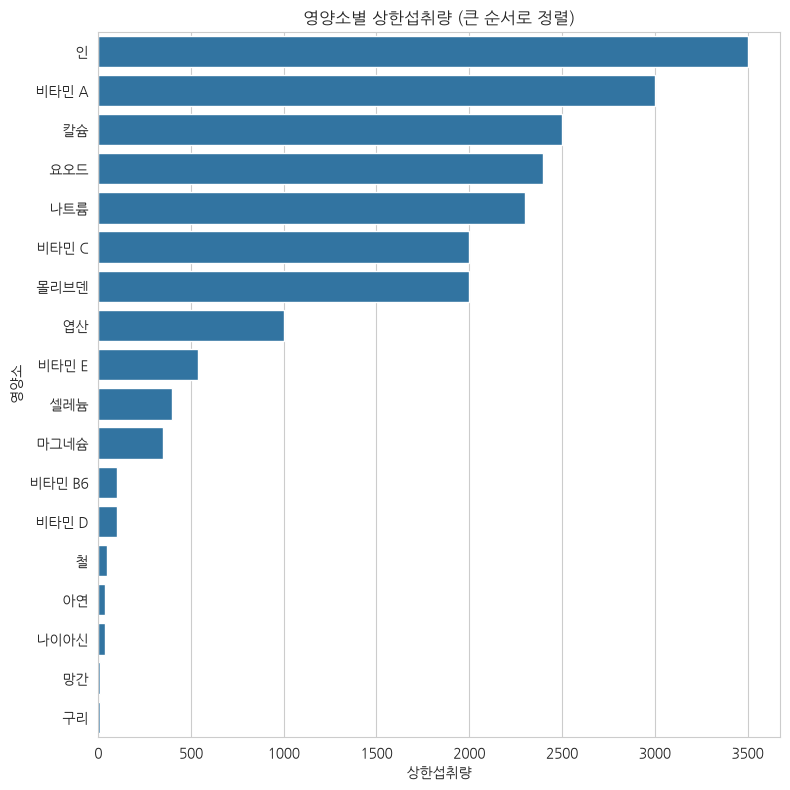

In [15]:
ul_summary = rda_db.groupby("영양소")["상한섭취량_숫자"].first().dropna().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(x=ul_summary.values, y=ul_summary.index, ax=ax, orient="h")
ax.set_title("영양소별 상한섭취량 (큰 순서로 정렬)")
ax.set_xlabel("상한섭취량")
ax.set_ylabel("영양소")
plt.tight_layout()
plt.show()


In [16]:
# 반대로, 상한섭취량 값 자체가 아예 없는(모두 결측인) 영양소도 확인해봅시다.
no_ul = rda_db.groupby("영양소")["상한섭취량_숫자"].apply(lambda s: s.notna().sum() == 0)
print("상한섭취량 데이터가 전혀 없는 영양소:")
list(no_ul[no_ul].index)


상한섭취량 데이터가 전혀 없는 영양소:


['비오틴', '비타민 B1', '비타민 B12', '비타민 B2', '비타민 K', '염소', '칼륨', '크롬', '판토텐산']

### 해석해보기

막대그래프를 보면 실제로 상한섭취량이 큰 영양소는 **인(3500mg), 비타민A(3000μg RAE),
칼슘(2500mg), 요오드(2400μg), 나트륨(2300mg)** 순입니다. 대부분 몸에서 매일 많은 양을 쓰는
다량 영양소(칼슘·인·나트륨)이거나 단위 자체가 커서(μg RAE, μg) 숫자가 크게 보이는 경우입니다.

주의할 점은 **칼륨은 이 목록에 아예 없다**는 것입니다. `칼륨`은 상한섭취량 값이 전부 결측이라
막대그래프에도 나타나지 않았습니다(27개 영양소 중 18개만 막대로 표시됨). 이는 "칼륨은
아무리 먹어도 안전하다"는 뜻이 아니라, **이 데이터셋에 칼륨의 상한섭취량 정보 자체가 없다**는
뜻입니다. 위에서 확인한 것처럼 비타민 B1·B2·B12·K, 비오틴, 판토텐산, 크롬, 염소, 칼륨은 모두
상한섭취량 데이터가 없습니다.

> 기획자 관점에서는 이 차이가 중요합니다. RF-4.2(과다섭취 경고)를 만들 때, 상한섭취량이 없는
> 영양소는 "안전하다"고 오해해서 경고를 생략하면 안 되고, **"이 영양소는 상한섭취량 기준이
> 없어 경고 대상에서 제외됨"** 처럼 데이터 부재를 명확히 구분해서 안내해야 합니다.

In [17]:
# 실습 2: 단위(단위 컬럼)별로 그룹을 나누어 다시 확인해봅시다.
# 같은 그래프에 mg와 μg 단위가 섞여 있으면 값 크기를 오해하기 쉽습니다.
rda_db.groupby("단위")["상한섭취량_숫자"].describe()


,count,mean,std,min,25%,50%,75%,max
단위,,,,,,,,
mg,86.0,1115.093023,1269.444655,10.0,35.0,350.0,2300.0,3500.0
mg NE,8.0,35.000000,0.000000,35.0,35.0,35.0,35.0,35.0
mg α-TE,8.0,540.000000,0.000000,540.0,540.0,540.0,540.0,540.0
μg,36.0,1227.777778,1024.168265,100.0,100.0,1200.0,2400.0,2400.0
μg DFE,10.0,1000.000000,0.000000,1000.0,1000.0,1000.0,1000.0,1000.0
μg RAE,8.0,3000.000000,0.000000,3000.0,3000.0,3000.0,3000.0,3000.0


---
## 3. 표현 불일치 확인 : 파일 간 조인(JOIN)이 가능한가?

> **이론 복습** : "같은 대상이 다른 표현으로 적혀 있으면" AI는 같은 대상을 다르게 인식합니다.
> 예: "서울" / "서울시" / "Seoul"

`상품마스터.csv`의 `검색키워드(주요원료)`와 `영양소_기능성_추천DB_확장판.csv`의 `영양소`는
같은 값을 가리켜야 두 파일을 조인해서 RF-1(맞춤 추천) 로직을 만들 수 있습니다.

In [18]:
product_keywords = set(product["검색키워드(주요원료)"].unique())
func_nutrients = set(func_db["영양소"].unique())

unmatched = product_keywords - func_nutrients
print("상품마스터에는 있지만 기능성DB에는 없는 영양소명:", unmatched if unmatched else "없음 (표현 일치)")


상품마스터에는 있지만 기능성DB에는 없는 영양소명: 없음 (표현 일치)


In [19]:
# 실제로 조인해서 몇 건이 매칭되는지 확인합니다.
merged = product.merge(
    func_db,
    left_on=["검색키워드(주요원료)", "관련_증상"],
    right_on=["영양소", "관련_증상"],
    how="left",
    indicator=True,
)
print(merged["_merge"].value_counts())
merged[merged["_merge"] == "left_only"][["상품ID", "상품명", "검색키워드(주요원료)", "관련_증상"]]


_merge
both          44
left_only      0
right_only     0
Name: count, dtype: int64


,상품ID,상품명,검색키워드(주요원료),관련_증상


### 해석해보기
`_merge` 결과가 전부 `both`라면, 두 파일의 표현이 일치해 **RF-1 추천 로직(건강고민 → 영양소 → 상품)** 을
바로 만들 수 있는 상태라는 뜻입니다. `left_only`가 있다면 표현이 다른 값이 남아 있다는 뜻이므로,
전처리(표현 통일)가 더 필요합니다.

---
## 4. 데이터 신뢰도 확인 : RF-3(AI 상담/RAG) 근거로 쓸 수 있는가?

> **이론 복습** : "출처가 불분명하면 사용자가 답변을 믿기 어렵다." (챗봇 AI에서 생기는 문제)

`영양소_기능성_추천DB`의 `근거_수준`과 `출처_URL`을 확인해, 실제로 인용 가능한 근거가
얼마나 되는지 살펴봅니다.

근거_수준
MFDS              52
Meta-analysis      1
Clinical Study     1
Name: count, dtype: int64


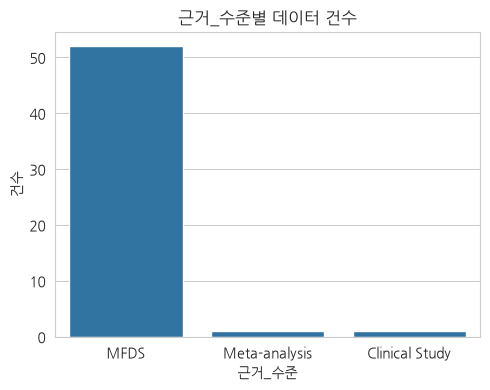

In [20]:
level_counts = func_db["근거_수준"].value_counts()
print(level_counts)

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=level_counts.index, y=level_counts.values, ax=ax)
ax.set_title("근거_수준별 데이터 건수")
ax.set_ylabel("건수")
plt.tight_layout()
plt.show()


### 해석해보기

`근거_수준`은 **MFDS(식약처 고시) 52건(96.3%)**, Meta-analysis·Clinical Study 각 1건(각 1.9%)입니다.
거의 모든 데이터가 식약처가 공식 인정한 기능성 근거이므로, RF-3 RAG 챗봇이 인용하기에
신뢰도가 매우 높은 데이터셋이라고 볼 수 있습니다. 다만 아래에서 보듯 MFDS 근거가 아닌 2건은
출처 URL도 없어 별도로 취급해야 합니다.

In [21]:
verifiable = func_db["출처_URL"].notna() & (func_db["출처_URL"] != "")
print(f"출처 URL로 검증 가능한 데이터: {verifiable.sum()} / {len(func_db)} 건")
print(f"검증 불가(개별 확인 필요) 데이터: {(~verifiable).sum()} 건")
func_db[~verifiable][["영양소", "기능성", "근거_수준", "출처"]]


출처 URL로 검증 가능한 데이터: 52 / 54 건
검증 불가(개별 확인 필요) 데이터: 2 건


,영양소,기능성,근거_수준,출처
52,비타민 C,감기 지속기간 감소,Meta-analysis,"학술 메타분석 문헌(강의용 예시 — 특정 논문 미상, 개별 검증 필요)"
53,마그네슘,수면 질 개선,Clinical Study,"임상연구 문헌(강의용 예시 — 특정 논문 미상, 개별 검증 필요)"


### 생각해보기
RAG 챗봇(RF-3.2, RF-3.3)이 **"근거 문서를 인용"** 하려면, 위에서 확인한 `출처_URL`이 있는 데이터를
우선 검색 대상으로 삼아야 합니다. 출처가 불분명한 2건은 어떻게 안내하는 것이 좋을지 토론해봅시다.

- 챗봇이 이 내용을 답변에 활용해도 될까요?
- 활용한다면, 사용자에게 어떻게 신뢰도를 안내해야 할까요?

---
## 5. RF-1~4 기능별 데이터 준비도 점검

각 건강 고민(관련_증상)마다 추천할 수 있는 상품이 실제로 몇 개나 있는지 확인합니다.
너무 적으면 "추천할 상품이 없는 건강 고민"이 생길 수 있습니다.

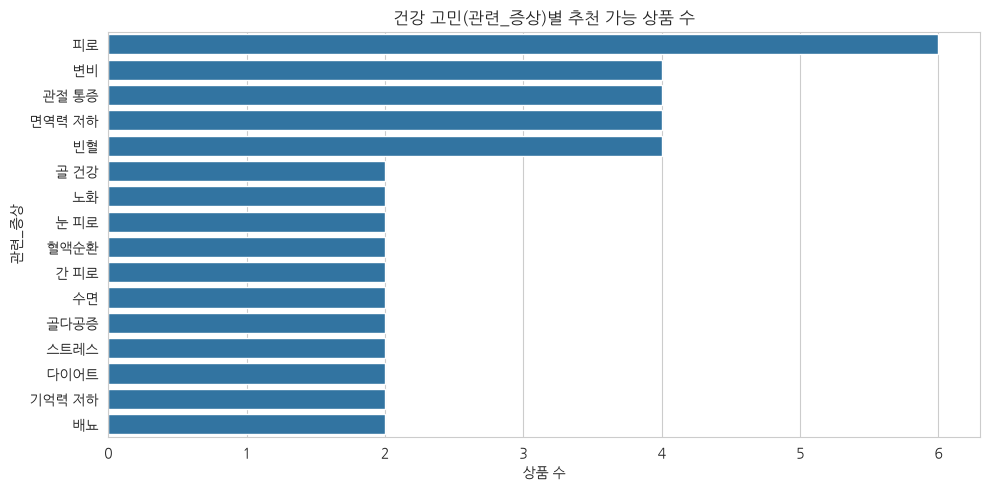

In [22]:
symptom_counts = product["관련_증상"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=symptom_counts.values, y=symptom_counts.index, ax=ax)
ax.set_title("건강 고민(관련_증상)별 추천 가능 상품 수")
ax.set_xlabel("상품 수")
plt.tight_layout()
plt.show()


### 해석해보기
`관련_증상`은 최소 2건("골 건강", "노화" 등)에서 최대 6건("피로")까지, 총 16개 건강 고민 모두
2개 이상의 상품을 가지고 있습니다. 즉 RF-1(맞춤 추천)이 "추천할 상품이 없는 건강 고민" 없이
최소한의 추천 커버리지는 확보한 상태입니다. 다만 표본 자체가 44건으로 적어서, 실제 서비스에서는
"피로 6건 vs 골 건강 2건"처럼 건강 고민별 상품 수 편차가 추천 다양성에 영향을 줄 수 있습니다.

In [23]:
# 실습 3: 상품이 1개 이하인 건강 고민을 찾아봅시다.
# 이런 건강 고민은 재추천(RF-1.4) 기능이 사실상 동작하기 어렵습니다.
thin_coverage = symptom_counts[symptom_counts <= 1]
print("상품이 1개 이하인 건강 고민:")
thin_coverage


상품이 1개 이하인 건강 고민:


Series([], Name: count, dtype: int64)

### 카테고리 분포도 함께 확인해봅니다.

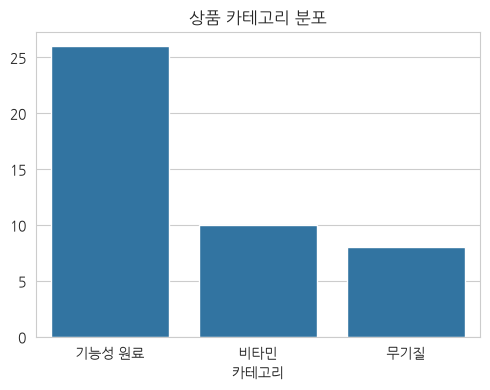

In [24]:
category_counts = product["카테고리"].value_counts()
fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=category_counts.index, y=category_counts.values, ax=ax)
ax.set_title("상품 카테고리 분포")
plt.tight_layout()
plt.show()


### 해석해보기
카테고리는 **기능성 원료 26건(59%), 비타민 10건(23%), 무기질 8건(18%)** 순입니다. 상품 절반 이상이
"기능성 원료"(루테인, 오메가3, 프로바이오틱스 등)에 몰려 있습니다. 이 비중은 바로 다음에 확인할
"RF-4 복용정보 데이터 커버리지"와 직결됩니다 — 기능성 원료는 한국인 영양소 섭취기준(KDRIs)에
권장·상한섭취량이 정의되어 있지 않은 경우가 많기 때문입니다.

### RF-4 복용정보(권장·상한섭취량) 데이터 커버리지 점검

요구사항정의서의 RF-4.0은 "권장/상한 섭취량 표시 → 과다섭취 경고"입니다. 이 기능이 실제로
동작하려면, 상품마스터의 `검색키워드(주요원료)`가 `영양소별_권장섭취량` 파일의 `영양소`와
매칭되어야 합니다. Section 3에서는 `영양소_기능성_추천DB`와의 매칭(표현 일치)만 확인했으므로,
이번에는 RF-4에 실제로 필요한 `영양소별_권장섭취량`과의 매칭을 별도로 확인해봅니다.

In [25]:
rda_nutrients = set(rda_db["영양소"].unique())
product["RDA_커버여부"] = product["검색키워드(주요원료)"].isin(rda_nutrients)

coverage_by_category = product.groupby("카테고리")["RDA_커버여부"].agg(["sum", "count"])
coverage_by_category["커버율(%)"] = (coverage_by_category["sum"] / coverage_by_category["count"] * 100).round(1)
coverage_by_category.columns = ["커버 상품 수", "전체 상품 수", "커버율(%)"]
print(f"전체 커버율: {product['RDA_커버여부'].sum()} / {len(product)} 건 "
      f"({product['RDA_커버여부'].mean()*100:.1f}%)")
coverage_by_category


전체 커버율: 18 / 44 건 (40.9%)


,커버 상품 수,전체 상품 수,커버율(%)
카테고리,,,
기능성 원료,0,26,0.0
무기질,8,8,100.0
비타민,10,10,100.0


In [26]:
uncovered = sorted(product.loc[~product["RDA_커버여부"], "검색키워드(주요원료)"].unique())
print("권장·상한섭취량 데이터가 없는 원료(RF-4 표시 불가):")
uncovered


권장·상한섭취량 데이터가 없는 원료(RF-4 표시 불가):


['MSM',
 '가르시니아 캄보지아 추출물',
 '글루코사민',
 '루테인',
 '밀크씨슬 추출물',
 '쏘팔메토 열매 추출물',
 '오메가3(EPA/DHA)',
 '은행잎 추출물',
 '차전자피 식이섬유',
 '코엔자임Q10',
 '테아닌',
 '프로바이오틱스',
 '홍삼']

### 해석해보기

전체 44개 상품 중 `영양소별_권장섭취량`에 매칭되는 상품은 **18건(40.9%)** 뿐입니다.
카테고리별로 나눠보면 원인이 명확합니다.

- **비타민(10/10, 100%), 무기질(8/8, 100%)** : KDRIs가 다루는 전형적인 영양소라 전부 커버됩니다.
- **기능성 원료(0/26, 0%)** : 루테인, 오메가3, 프로바이오틱스, 밀크씨슬, 코엔자임Q10, 홍삼,
  글루코사민, MSM, 은행잎 추출물, 쏘팔메토, 테아닌, 가르시니아, 차전자피처럼 건강기능식품에서
  흔히 쓰이는 원료는 **KDRIs 제도 자체가 권장·상한섭취량을 정의하지 않습니다.**

즉 상품 카테고리 비중(기능성 원료 59%)과 RDA 데이터 커버리지(기능성 원료 0%)가 정반대로 엇갈립니다.
지금 데이터만으로는 **상품의 절반 이상에서 RF-4(권장/상한 섭취량 표시)를 구현할 수 없다**는 뜻이며,
이 원료들은 "섭취시주의사항" 같은 정성적 텍스트 안내로 대체하거나, 제조사가 자체 공시한
1일 섭취 권장량 데이터를 별도로 확보해야 합니다.

### RF-4.2 과다섭취 경고 실현 가능성 점검

요구사항정의서에는 리스크가 큰 요구사항으로 **RF-4.2 "여러 제품을 함께 담을 경우 특정 영양소의
합산 섭취량이 상한섭취량을 초과하면 경고를 표시"** 가 명시되어 있고, 오류 시 건강 영향이 크다는
이유로 AI가 아닌 규칙 기반으로 설계하기로 변경되었습니다.

규칙 기반이라도 "합산 섭취량"을 계산하려면 **상품 1개당 특정 영양소가 몇 mg/μg 들어있는지**가
필요합니다. `상품마스터`의 `섭취량_섭취방법`에 그 정보가 들어있는지 확인해봅시다.

In [27]:
# "섭취량_섭취방법" 텍스트에 영양소 함량(mg/μg 등) 숫자가 실제로 적혀 있는지 확인해봅시다.
has_amount = product["섭취량_섭취방법"].str.contains(r"mg|㎎|mcg|㎍|μg", na=False)
print(f"성분 함량(mg/μg)이 텍스트에 표기된 상품: {has_amount.sum()} / {len(product)} 건")
product[has_amount][["상품ID", "상품명", "섭취량_섭취방법"]]


성분 함량(mg/μg)이 텍스트에 표기된 상품: 1 / 44 건


,상품ID,상품명,섭취량_섭취방법
18,P019,관절 연골 MSM 1500,"1일 1회, 1회 3정 (1,500mg)을 충분한 물과 함께 섭취"


### 해석해보기

44건 중 **단 1건**(P019, MSM 1500)만 `섭취량_섭취방법`에 "1,500mg"이 적혀 있고, 그마저도
정제 전체 중량인지 MSM 순수 함량인지 텍스트만으로는 확실하지 않습니다. 나머지 43건은
"1회 1포(2.1g)", "1회 1캡슐"처럼 **포장 단위·중량**만 있을 뿐, 그 안에 들어있는 영양소 함량은
전혀 알 수 없습니다.

즉, 지금 수집된 데이터로는 **RF-4.2(여러 제품 합산 시 상한섭취량 초과 경고)를 규칙 기반으로도
구현할 수 없습니다.** 이 기능을 실제로 만들려면 상품마스터에 없는 **"1일 섭취량당 영양소 함량표"**
(예: 비타민C 500mg/포와 같은 정량 데이터)를 별도 컬럼이나 테이블로 추가 수집해야 합니다.
이는 Day 04 RDB 설계에서 "상품-영양소-함량" 관계를 별도 테이블로 분리해야 하는 이유이기도 합니다.

---
## 6. 텍스트 데이터 품질 확인 (RAG 문서로 쓰기 전 점검)

`기능성_내용`, `섭취시주의사항`처럼 긴 텍스트 컬럼은 RAG 챗봇의 답변 근거로 쓰입니다.
너무 짧거나 비어 있는 텍스트는 챗봇이 부실한 답변을 하게 만들 수 있습니다. (데이터 품질과 전처리 이해.md - "문서에 빈 내용이 많으면 답변이 부실해진다")

In [28]:
text_cols = ["기능성_내용", "섭취시주의사항", "섭취량_섭취방법"]
for col in text_cols:
    lengths = product[col].fillna("").str.len()
    print(f"[{col}] 평균 길이: {lengths.mean():.0f}자 / 최소: {lengths.min()}자 / 빈 값: {(lengths == 0).sum()}건")


[기능성_내용] 평균 길이: 184자 / 최소: 25자 / 빈 값: 0건
[섭취시주의사항] 평균 길이: 192자 / 최소: 0자 / 빈 값: 1건
[섭취량_섭취방법] 평균 길이: 30자 / 최소: 21자 / 빈 값: 0건


In [29]:
# 실습 4: 텍스트 길이가 너무 짧은(예: 20자 미만) 상품을 찾아, 왜 짧은지 원문을 확인해봅시다.
short_texts = product[product["기능성_내용"].fillna("").str.len() < 20]
short_texts[["상품ID", "상품명", "기능성_내용"]]


,상품ID,상품명,기능성_내용


### 해석해보기

`기능성_내용`은 평균 184자, 최소 25자로 20자 미만인 상품이 없어 RF-3 RAG 챗봇이 인용할 만한
최소 분량은 확보되어 있습니다. 다만 `섭취시주의사항`은 최솟값이 0자, 즉 **1건은 완전히 비어
있습니다.** Section 1에서 확인한 결측 1건과 같은 행입니다. RAG 챗봇이 이 상품에 대해 주의사항을
질문받으면 근거 문서가 없어 "정보 없음"으로 답하거나 CS로 이관해야 하며, 없는 내용을
지어내서(hallucination) 답하지 않도록 주의해야 합니다.

---
## 정리

이번 실습에서 확인한 것:

1. **결측치**는 무조건 오류가 아니라, 제도·데이터 구조상 정상적으로 비어 있는 값일 수 있다.
   (권장섭취량/충분섭취량, 근거 논문 미상 출처) 하지만 **일반 규칙만 믿고 넘기면 안 되며**,
   비타민D 임산부·수유부 사례처럼 같은 영양소의 다른 행과 비교했을 때 패턴이 깨지는 결측치는
   진짜 입력 누락일 가능성이 높다.
2. **이상치**를 확인하려면 단위를 먼저 맞춰야 하며, 단위가 섞이면 잘못된 판단을 할 수 있다.
   또한 상한섭취량이 아예 없는 영양소(칼륨 등)를 "안전해서 없는 것"으로 오해하면 안 된다.
3. **표현 일치**가 되어 있어야 여러 데이터 파일을 조인해 추천 로직(RF-1)을 만들 수 있다.
4. **출처가 명확한 데이터**(MFDS 근거 96.3%)만 RAG 챗봇(RF-3)의 근거로 인용하는 것이 안전하다.
5. 건강 고민별 상품 수, 텍스트 길이처럼 **"기능이 실제로 동작할 만큼 데이터가 충분한가"** 도
   전처리 이전에 확인해야 할 품질 기준이다.
6. **RF-4(복용정보)는 상품의 40.9%만 구현 가능하다.** 비타민·무기질은 100% 커버되지만,
   상품 비중이 더 큰 "기능성 원료"(59%)는 KDRIs 상한섭취량 데이터가 아예 없다.
7. **RF-4.2(과다섭취 경고)는 지금 데이터로는 규칙 기반으로도 만들 수 없다.** 상품마스터에
   포장 단위(포·캡슐 수·중량)는 있지만, 정작 필요한 "영양소 함량(mg/μg)"이 없기 때문이다.

> 좋은 AI는 좋은 모델만으로 만들어지지 않습니다. AI가 믿고 사용할 수 있는 데이터가 있어야 좋은 서비스가 됩니다.
